# NLP CLASSIFICATION OF E-COMMERCE PRODUCTS

In [42]:

# ============================================
# 1. INSTALLATION DES PACKAGES (si nécessaire)
# ============================================

!pip install pandas numpy scikit-learn matplotlib seaborn nltk openpyxl

# ============================================
# 2. IMPORT DES BIBLIOTHÈQUES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK pour le NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Scikit-learn pour le ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Télécharger les ressources NLTK
nltk.download('stopwords')
nltk.download('punkt')

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [43]:
# ============================================
# 3. CHARGEMENT ET NETTOYAGE DES DONNÉES
# ============================================

# Charger le fichier
df = pd.read_csv('file.csv', encoding='utf-8')
print(f"📊 Données brutes: {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(10)

📊 Données brutes: 360 lignes, 4 colonnes


,Category,Product_name,Note,Prix
0,Les meilleures ventes en Cuisine et Maison - V...,Philips Rasoir Anti-Bouloche/Anti-Peluche - El...,"4,5 sur 5 étoiles","29,99 €"
1,Les meilleures ventes en Cuisine et Maison - V...,"De'Longhi EcoDecalk Détartrant DLSC500, 5 Dose...","4,8 sur 5 étoiles","29,99 €"
2,Les meilleures ventes en Cuisine et Maison - V...,"Amazon Basics Drap Housse, 160 x 200 x 30 cm, ...","4,5 sur 5 étoiles","29,99 €"
3,Les meilleures ventes en Cuisine et Maison - V...,Sanytol - Lingettes Multi-Usages Désinfectante...,"4,7 sur 5 étoiles","29,99 €"
4,Les meilleures ventes en Cuisine et Maison - V...,"De'Longhi Cartouche Filtrante DLSC002, Filtre ...","4,7 sur 5 étoiles","29,99 €"
5,Les meilleures ventes en Cuisine et Maison - V...,Utopia Bedding Protège Matelas 160 x 200 x 30 ...,"4,6 sur 5 étoiles","29,99 €"
6,Les meilleures ventes en Cuisine et Maison - V...,Dreamzie - Protege Matelas 160x200 cm - Imperm...,"4,5 sur 5 étoiles","29,99 €"
7,Les meilleures ventes en Cuisine et Maison - V...,"Rowenta Lot de 4 sacs Hygiène+, Compatibles av...","4,7 sur 5 étoiles","29,99 €"
8,Les meilleures ventes en Cuisine et Maison - V...,"Utopia Bedding Drap Housse - Gris, 180 x 200 c...","4,6 sur 5 étoiles","29,99 €"
9,Les meilleures ventes en Cuisine et Maison - V...,De Buyer - Fouet professionnel fils en inox GO...,"4,8 sur 5 étoiles","29,99 €"


In [44]:
# Fonctions de nettoyage
def nettoyer_prix(prix):
    """Nettoie la colonne prix"""
    if pd.isna(prix):
        return None
    prix_propre = re.sub(r'[^\d,]', '', str(prix))
    prix_propre = prix_propre.replace(',', '.')
    return float(prix_propre) if prix_propre else None

def nettoyer_note(note):
    """Nettoie la colonne note"""
    if pd.isna(note):
        return None
    match = re.search(r'(\d+[.,]\d+)', str(note))
    if match:
        return float(match.group(1).replace(',', '.'))
    return None

def nettoyer_categorie(cat):
    """Nettoie la catégorie"""
    if pd.isna(cat):
        return ""
    cat_propre = str(cat).replace('Les meilleures ventes en ', '').replace(' - Voir plus', '')
    return cat_propre.strip()

def nettoyer_nom_produit(nom):
    """Nettoie le nom du produit"""
    if pd.isna(nom):
        return ""
    return str(nom).strip(' "\'')



df['Category'] = df['Category'].apply(nettoyer_categorie)
df['Product_name'] = df['Product_name'].apply(nettoyer_nom_produit)
df['Note'] = df['Note'].apply(nettoyer_note)
df['Prix'] = df['Prix'].apply(nettoyer_prix)

# Supprimer les lignes vides
df = df.dropna(subset=['Product_name', 'Prix'], how='all')
df = df[df['Product_name'].str.strip() != '']
df = df[df['Category'].str.strip() != '']
df = df.reset_index(drop=True)

print(f" Données nettoyées: {df.shape[0]} produits")
df.head(10)

 Données nettoyées: 322 produits


,Category,Product_name,Note,Prix
0,Cuisine et Maison,Philips Rasoir Anti-Bouloche/Anti-Peluche - El...,4.5,29.99
1,Cuisine et Maison,"De'Longhi EcoDecalk Détartrant DLSC500, 5 Dose...",4.8,29.99
2,Cuisine et Maison,"Amazon Basics Drap Housse, 160 x 200 x 30 cm, ...",4.5,29.99
3,Cuisine et Maison,Sanytol - Lingettes Multi-Usages Désinfectante...,4.7,29.99
4,Cuisine et Maison,"De'Longhi Cartouche Filtrante DLSC002, Filtre ...",4.7,29.99
5,Cuisine et Maison,Utopia Bedding Protège Matelas 160 x 200 x 30 ...,4.6,29.99
6,Cuisine et Maison,Dreamzie - Protege Matelas 160x200 cm - Imperm...,4.5,29.99
7,Cuisine et Maison,"Rowenta Lot de 4 sacs Hygiène+, Compatibles av...",4.7,29.99
8,Cuisine et Maison,"Utopia Bedding Drap Housse - Gris, 180 x 200 c...",4.6,29.99
9,Cuisine et Maison,De Buyer - Fouet professionnel fils en inox GO...,4.8,29.99


📊 STATISTIQUES GÉNÉRALES
--------------------------------------------------
Nombre total de produits: 322
Nombre de catégories: 6
Prix moyen: 29.99 €
Note moyenne: 4.49/5
Prix min: 29.99 €
Prix max: 29.99 €

📊 DISTRIBUTION DES CATÉGORIES
--------------------------------------------------
Bricolage: 60 produits (18.6%)
Hygiène et Santé: 60 produits (18.6%)
Sports et Loisirs: 60 produits (18.6%)
Cuisine et Maison: 59 produits (18.3%)
Mode: 59 produits (18.3%)
Luminaires et Éclairage: 24 produits (7.5%)


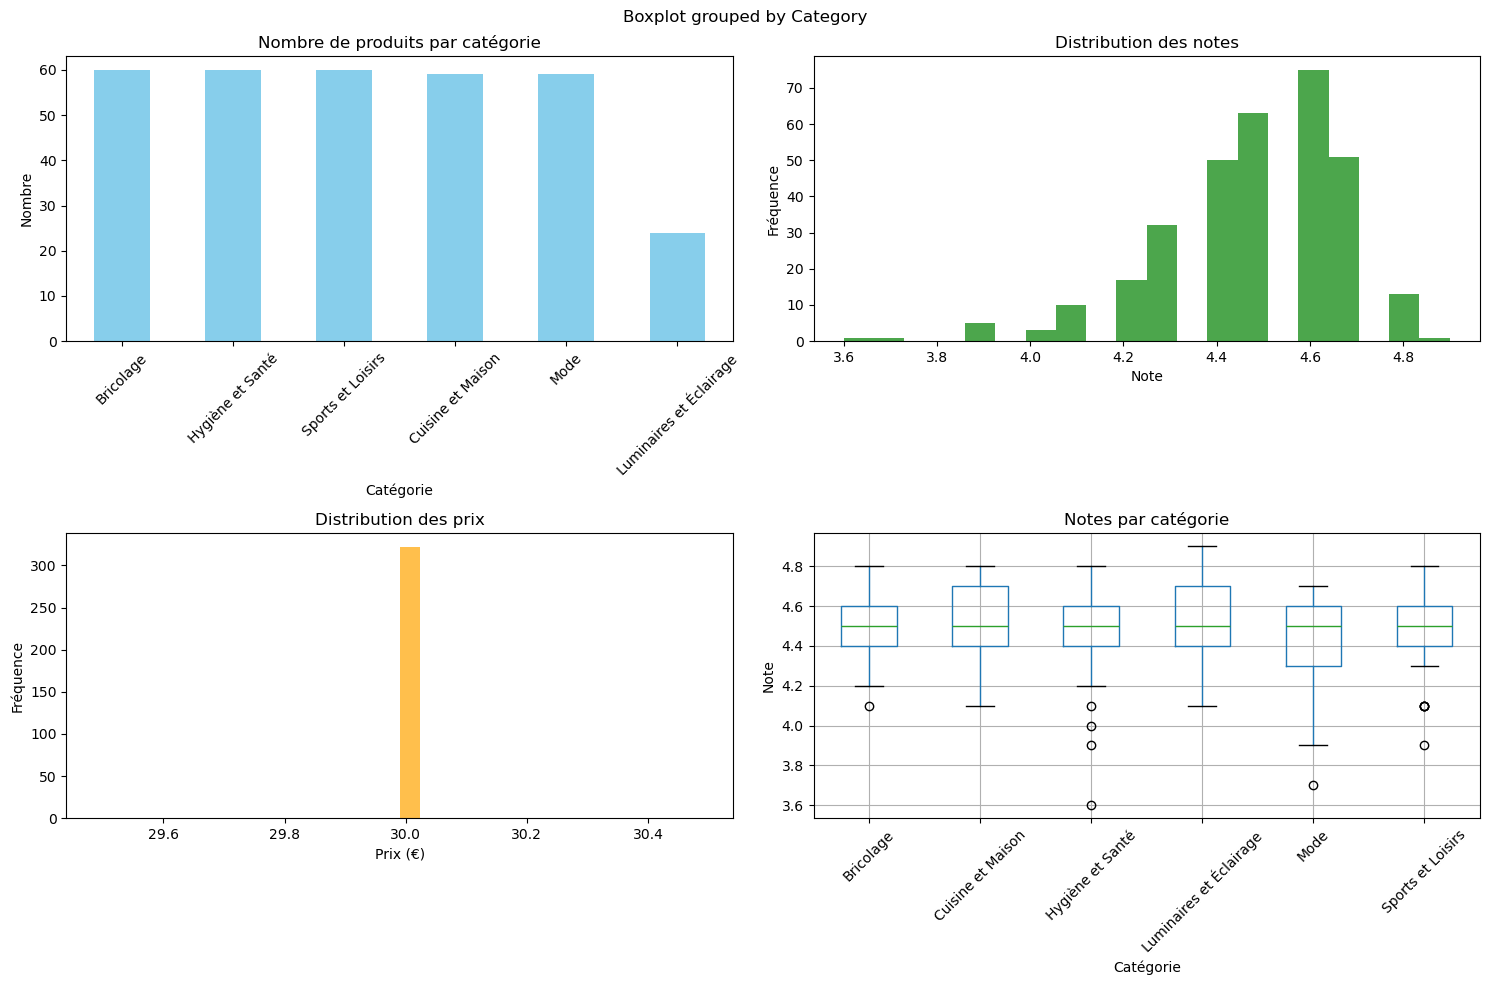

In [45]:
# ============================================
# 4. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ============================================

# Statistiques générales
print("📊 STATISTIQUES GÉNÉRALES")
print("-" * 50)
print(f"Nombre total de produits: {len(df)}")
print(f"Nombre de catégories: {df['Category'].nunique()}")
print(f"Prix moyen: {df['Prix'].mean():.2f} €")
print(f"Note moyenne: {df['Note'].mean():.2f}/5")
print(f"Prix min: {df['Prix'].min():.2f} €")
print(f"Prix max: {df['Prix'].max():.2f} €")

# Distribution des catégories
print("\n📊 DISTRIBUTION DES CATÉGORIES")
print("-" * 50)
cat_counts = df['Category'].value_counts()
for cat, count in cat_counts.items():
    print(f"{cat}: {count} produits ({count/len(df)*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution des catégories
cat_counts.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Nombre de produits par catégorie')
axes[0,0].set_xlabel('Catégorie')
axes[0,0].set_ylabel('Nombre')
axes[0,0].tick_params(axis='x', rotation=45)

# Distribution des notes
axes[0,1].hist(df['Note'].dropna(), bins=20, color='green', alpha=0.7)
axes[0,1].set_title('Distribution des notes')
axes[0,1].set_xlabel('Note')
axes[0,1].set_ylabel('Fréquence')

# Distribution des prix
axes[1,0].hist(df['Prix'].dropna(), bins=30, color='orange', alpha=0.7)
axes[1,0].set_title('Distribution des prix')
axes[1,0].set_xlabel('Prix (€)')
axes[1,0].set_ylabel('Fréquence')

# Boxplot des notes par catégorie
df.boxplot(column='Note', by='Category', ax=axes[1,1], rot=45)
axes[1,1].set_title('Notes par catégorie')
axes[1,1].set_xlabel('Catégorie')
axes[1,1].set_ylabel('Note')

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# 5. PRÉPARATION DES DONNÉES POUR LE NLP
# ============================================

# Initialiser les outils NLP
stop_words = set(stopwords.words('french'))
stemmer = SnowballStemmer('french')

def preprocess_texte(texte):
    """Prétraite le texte pour le NLP"""
    if pd.isna(texte) or texte == "":
        return ""
    
    # Mettre en minuscules
    texte = texte.lower()
    
    # Supprimer la ponctuation et les caractères spéciaux
    texte = re.sub(r'[^\w\s]', ' ', texte)
    
    # Supprimer les chiffres
    texte = re.sub(r'\d+', '', texte)
    
    # Tokeniser
    mots = texte.split()
    
    # Supprimer les stop words et appliquer le stemming
    mots = [stemmer.stem(mot) for mot in mots if mot not in stop_words and len(mot) > 2]
    
    return ' '.join(mots)

# Appliquer le prétraitement
df['texte_prepare'] = df['Product_name'].apply(preprocess_texte)

print("Exemples de textes prétraités:")
for i in range(5):
    print(f"\nOriginal: {df['Product_name'].iloc[i][:50]}...")
    print(f"Prétraité: {df['texte_prepare'].iloc[i][:50]}...")

Exemples de textes prétraités:

Original: Philips Rasoir Anti-Bouloche/Anti-Peluche - Elimin...
Prétraité: philip rasoir anti bouloch anti peluch elimin boul...

Original: De'Longhi EcoDecalk Détartrant DLSC500, 5 Doses de...
Prétraité: longh ecodecalk détartr dlsc dos décalcif accessoi...

Original: Amazon Basics Drap Housse, 160 x 200 x 30 cm, en P...
Prétraité: amazon basic drap houss polyest microfibr matel ép...

Original: Sanytol - Lingettes Multi-Usages Désinfectantes Eu...
Prétraité: sanytol linget mult usag désinfect eucalyptus ling...

Original: De'Longhi Cartouche Filtrante DLSC002, Filtre a Ea...
Prétraité: longh cartouch filtr dlsc filtr eau machin caf bla...


In [47]:
# ============================================
# 6. DIVISION DES DONNÉES
# ============================================

# Garder seulement les catégories avec assez d'exemples (minimum 5)
min_exemples = 5
categories_counts = df['Category'].value_counts()
categories_valides = categories_counts[categories_counts >= min_exemples].index

df_filtre = df[df['Category'].isin(categories_valides)]

X = df_filtre['texte_prepare'].fillna('')
y = df_filtre['Category']

print(f"Catégories gardées ({len(categories_valides)}):")
for cat in categories_valides:
    count = len(df_filtre[df_filtre['Category'] == cat])
    print(f"  - {cat}: {count} exemples")

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Split terminé:")
print(f"  - Train: {len(X_train)} exemples")
print(f"  - Test: {len(X_test)} exemples")

Catégories gardées (6):
  - Bricolage: 60 exemples
  - Hygiène et Santé: 60 exemples
  - Sports et Loisirs: 60 exemples
  - Cuisine et Maison: 59 exemples
  - Mode: 59 exemples
  - Luminaires et Éclairage: 24 exemples

 Split terminé:
  - Train: 257 exemples
  - Test: 65 exemples


In [48]:
# ============================================
# 7. ENTRAÎNEMENT ET COMPARAISON DES MODÈLES
# ============================================

# Définir les modèles à tester
modeles = {
    'Naive Bayes': MultinomialNB(),
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

resultats = {}
predictions = {}

print(" ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)

for nom, modele in modeles.items():
    print(f"\n Entraînement: {nom}")
    
    # Créer le pipeline
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', modele)
    ])
    
    # Entraîner
    pipeline.fit(X_train, y_train)
    
    # Prédire
    y_pred = pipeline.predict(X_test)
    y_pred_train = pipeline.predict(X_train)
    
    # Évaluer
    accuracy_test = accuracy_score(y_test, y_pred)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    
    # Validation croisée
    cv_scores = cross_val_score(pipeline, X, y, cv=5)
    
    resultats[nom] = {
        'pipeline': pipeline,
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    predictions[nom] = y_pred
    
    print(f"   Accuracy (train): {accuracy_train:.4f}")
    print(f"   Accuracy (test): {accuracy_test:.4f}")
    print(f"   CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Trouver le meilleur modèle
meilleur_nom = max(resultats, key=lambda x: resultats[x]['accuracy_test'])
print(f"\n MEILLEUR MODÈLE: {meilleur_nom}")
print(f"    Accuracy test: {resultats[meilleur_nom]['accuracy_test']:.4f}")

 ENTRAÎNEMENT DES MODÈLES

 Entraînement: Naive Bayes
   Accuracy (train): 0.9883
   Accuracy (test): 0.7846
   CV Score: 0.7854 (+/- 0.1404)

 Entraînement: Régression Logistique
   Accuracy (train): 0.9883
   Accuracy (test): 0.8000
   CV Score: 0.7885 (+/- 0.1290)

 Entraînement: SVM
   Accuracy (train): 0.9922
   Accuracy (test): 0.8000
   CV Score: 0.8011 (+/- 0.0739)

 Entraînement: Random Forest
   Accuracy (train): 1.0000
   Accuracy (test): 0.6923
   CV Score: 0.6548 (+/- 0.1463)

 MEILLEUR MODÈLE: Régression Logistique
    Accuracy test: 0.8000


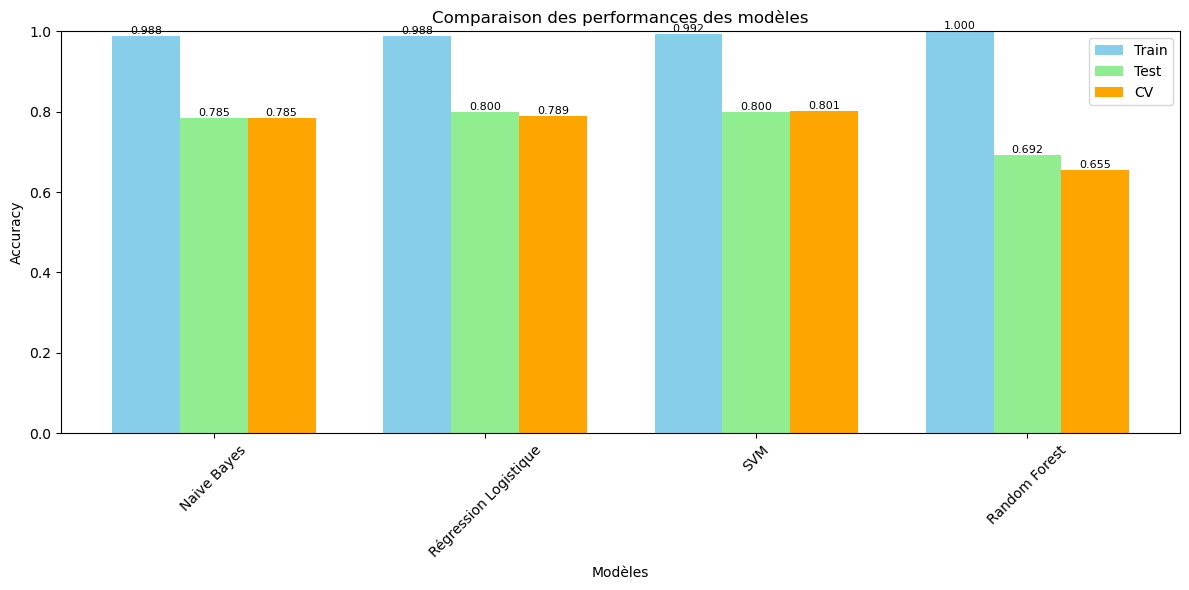

In [49]:
# ============================================
# 8. VISUALISATION DES RÉSULTATS
# ============================================

# Créer un dataframe des résultats
df_resultats = pd.DataFrame([
    {
        'Modèle': nom,
        'Train': res['accuracy_train'],
        'Test': res['accuracy_test'],
        'CV': res['cv_mean']
    }
    for nom, res in resultats.items()
])

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_resultats))
width = 0.25

bars1 = ax.bar(x - width, df_resultats['Train'], width, label='Train', color='skyblue')
bars2 = ax.bar(x, df_resultats['Test'], width, label='Test', color='lightgreen')
bars3 = ax.bar(x + width, df_resultats['CV'], width, label='CV', color='orange')

ax.set_xlabel('Modèles')
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison des performances des modèles')
ax.set_xticks(x)
ax.set_xticklabels(df_resultats['Modèle'], rotation=45)
ax.legend()
ax.set_ylim(0, 1)

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

📊 RAPPORT DE CLASSIFICATION - Régression Logistique
                         precision    recall  f1-score   support

              Bricolage       0.77      0.83      0.80        12
      Cuisine et Maison       0.77      0.83      0.80        12
       Hygiène et Santé       0.91      0.83      0.87        12
Luminaires et Éclairage       1.00      0.40      0.57         5
                   Mode       0.83      0.83      0.83        12
      Sports et Loisirs       0.71      0.83      0.77        12

               accuracy                           0.80        65
              macro avg       0.83      0.76      0.77        65
           weighted avg       0.81      0.80      0.80        65



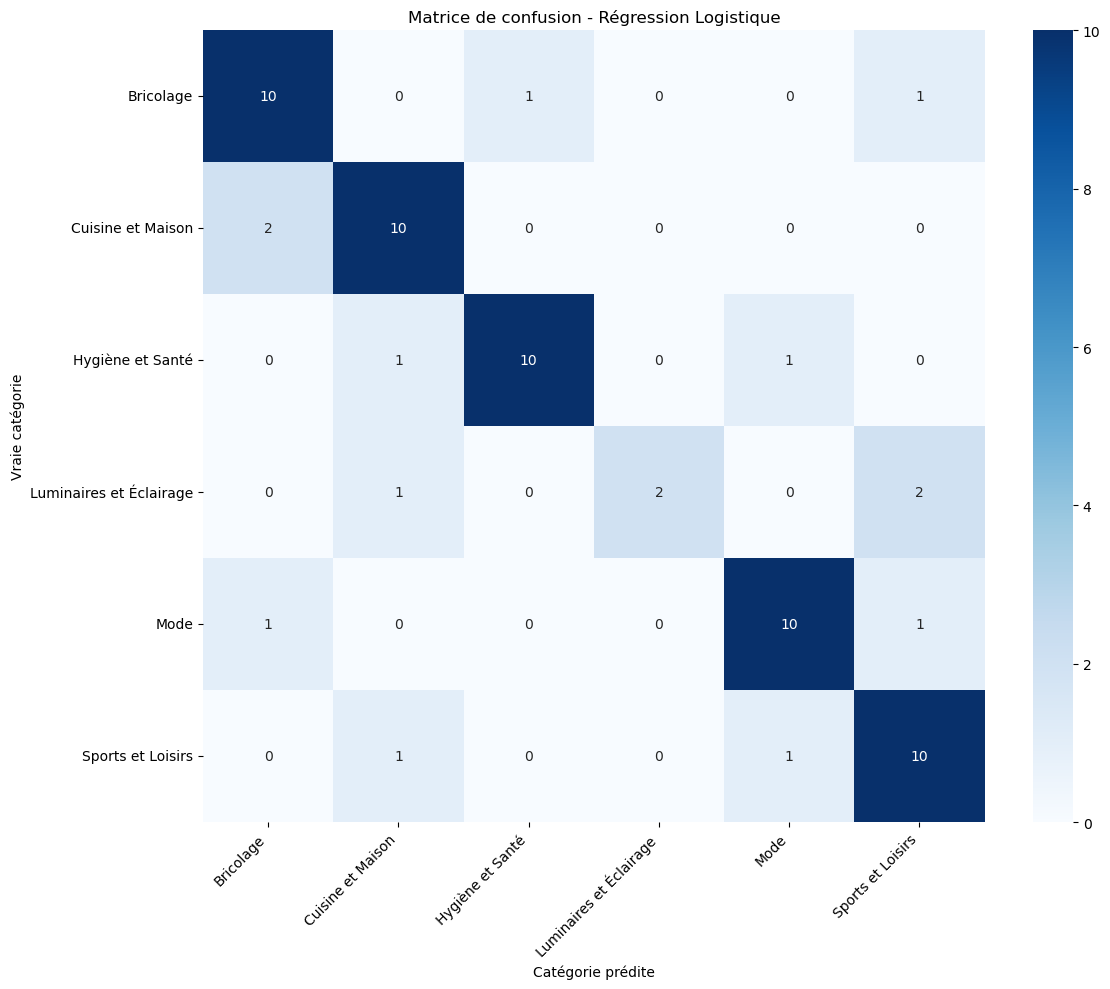

In [50]:
# ============================================
# 9. ÉVALUATION DÉTAILLÉE DU MEILLEUR MODÈLE
# ============================================

meilleur_pipeline = resultats[meilleur_nom]['pipeline']
y_pred = predictions[meilleur_nom]

# Rapport de classification
print(f"📊 RAPPORT DE CLASSIFICATION - {meilleur_nom}")
print("=" * 70)
print(classification_report(y_test, y_pred))

# Matrice de confusion
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=meilleur_pipeline.classes_,
            yticklabels=meilleur_pipeline.classes_)
plt.title(f'Matrice de confusion - {meilleur_nom}')
plt.ylabel('Vraie catégorie')
plt.xlabel('Catégorie prédite')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
# ============================================
# 10. FONCTION DE PRÉDICTION
# ============================================

def predire_categorie(nom_produit, modele=meilleur_pipeline, n_top=3):
    """
    Prédit la catégorie d'un produit
    """
    # Prétraiter le texte
    texte_prepare = preprocess_texte(nom_produit)
    
    # Prédire
    prediction = modele.predict([texte_prepare])[0]
    
    # Probabilités
    probabilites = modele.predict_proba([texte_prepare])[0]
    
    # Top N catégories
    top_indices = probabilites.argsort()[-n_top:][::-1]
    
    print(f"\n PRODUIT: {nom_produit}")
    print(f" CATÉGORIE PRÉDITE: {prediction}")
    print(f"\n Top {n_top} catégories:")
    print("-" * 40)
    
    for idx in top_indices:
        cat = modele.classes_[idx]
        prob = probabilites[idx] * 100
        print(f"{cat}: {prob:.2f}%")
    
    return prediction, [(modele.classes_[idx], probabilites[idx]) for idx in top_indices]

# Tester avec quelques produits
produits_test = [
    "Philips Rasoir Anti-Bouloche pour vêtements",
    "LEGO Botaniques Le Joli Bouquet de Fleurs",
    "Baranne Spray Imperméabilisant Chaussures",
    "Magnésium Bisglycinate Vitamine B6 Fatigue",
    "Tapis de Course Pliable pour Maison",
    "Cadenas Code 4 Chiffres pour Valise"
]

for produit in produits_test:
    predire_categorie(produit)
    print("\n" + "="*50)


 PRODUIT: Philips Rasoir Anti-Bouloche pour vêtements
 CATÉGORIE PRÉDITE: Cuisine et Maison

 Top 3 catégories:
----------------------------------------
Cuisine et Maison: 29.31%
Hygiène et Santé: 19.14%
Sports et Loisirs: 16.40%


 PRODUIT: LEGO Botaniques Le Joli Bouquet de Fleurs
 CATÉGORIE PRÉDITE: Cuisine et Maison

 Top 3 catégories:
----------------------------------------
Cuisine et Maison: 24.75%
Hygiène et Santé: 18.27%
Bricolage: 17.61%


 PRODUIT: Baranne Spray Imperméabilisant Chaussures
 CATÉGORIE PRÉDITE: Mode

 Top 3 catégories:
----------------------------------------
Mode: 28.80%
Hygiène et Santé: 17.72%
Sports et Loisirs: 16.28%


 PRODUIT: Magnésium Bisglycinate Vitamine B6 Fatigue
 CATÉGORIE PRÉDITE: Hygiène et Santé

 Top 3 catégories:
----------------------------------------
Hygiène et Santé: 42.11%
Bricolage: 13.60%
Sports et Loisirs: 13.37%


 PRODUIT: Tapis de Course Pliable pour Maison
 CATÉGORIE PRÉDITE: Sports et Loisirs

 Top 3 catégories:
---------------

In [52]:
# ============================================
# 11. ANALYSE DES ERREURS
# ============================================

# Identifier les erreurs de classification
erreurs = X_test[y_test != y_pred].index
print(f" NOMBRE D'ERREURS: {len(erreurs)}")

# Afficher quelques exemples d'erreurs
print("\n EXEMPLES D'ERREURS:")
print("-" * 80)

for i, idx in enumerate(erreurs[:10]):
    produit = df_filtre.loc[idx, 'Product_name']
    vrai = y_test[y_test.index == idx].values[0] if idx in y_test.index else "N/A"
    pred = y_pred[list(y_test.index).index(idx)] if idx in y_test.index else "N/A"
    
    print(f"\n{i+1}. Produit: {produit[:80]}...")
    print(f"   Vrai catégorie: {vrai}")
    print(f"   Prédit: {pred}")

 NOMBRE D'ERREURS: 13

 EXEMPLES D'ERREURS:
--------------------------------------------------------------------------------

1. Produit: GRIFEMA GA1001-1, Cadenas Code 4 Chiffres - Cadenas de Sécurité Résistant Aux In...
   Vrai catégorie: Bricolage
   Prédit: Sports et Loisirs

2. Produit: WEARXI Cadeau Saint Valentin Homme, 13 en 1 Couteau de Survie Pliant Multifoncti...
   Vrai catégorie: Sports et Loisirs
   Prédit: Mode

3. Produit: Joma Men's Sports T-Shirt, 6XS - 3XL - Short Sleeve, Lightweight and Breathable,...
   Vrai catégorie: Mode
   Prédit: Sports et Loisirs

4. Produit: AUDISPRAY ULTRA - Traitement Bouchon de cérumen - Dissolution rapide des bouchon...
   Vrai catégorie: Hygiène et Santé
   Prédit: Cuisine et Maison

5. Produit: Ruban LED COB 5M, bande LED blanche naturelle 4000K, bande LED dimmable 24V, lar...
   Vrai catégorie: Luminaires et Éclairage
   Prédit: Sports et Loisirs

6. Produit: Masque de Nuit Innovant 2026 pour Hommes et Femmes, Conception Masque de Som

In [53]:
# ============================================
# 12. SAUVEGARDE DU MODÈLE
# ============================================

import joblib

# Sauvegarder le meilleur modèle
joblib.dump(meilleur_pipeline, 'modele_classification.pkl')
print(" Modèle sauvegardé: modele_classification.pkl")

# Sauvegarder les données nettoyées
df.to_csv('produits_nettoyes.csv', index=False, encoding='utf-8-sig')
print(" Données sauvegardées: produits_nettoyes.csv")

# Sauvegarder les résultats
df_resultats.to_csv('resultats_modeles.csv', index=False)
print(" Résultats sauvegardés: resultats_modeles.csv")

 Modèle sauvegardé: modele_classification.pkl
 Données sauvegardées: produits_nettoyes.csv et .xlsx
 Résultats sauvegardés: resultats_modeles.csv


In [54]:
# ============================================
# 13. TEST AVEC UN NOUVEAU PRODUIT
# ============================================

def tester_nouveau_produit():
    """
    Interface simple pour tester un nouveau produit
    """
    print(" TESTEUR DE CLASSIFICATION")
    print("=" * 40)
    
    while True:
        produit = input("\nEntrez un nom de produit (ou 'quit' pour quitter): ")
        
        if produit.lower() == 'quit':
            break
        
        if produit.strip():
            predire_categorie(produit)
        else:
            print("Veuillez entrer un nom de produit valide")

# Décommenter pour tester interactivement
# tester_nouveau_produit()

In [55]:
# ============================================
# 14. STATISTIQUES FINALES
# ============================================

print(" RÉSUMÉ DU PROJET")
print("=" * 50)
print(f" Total produits: {len(df)}")
print(f" Catégories: {df['Category'].nunique()}")
print(f" Meilleur modèle: {meilleur_nom}")
print(f" Accuracy: {resultats[meilleur_nom]['accuracy_test']:.2%}")
print(f" Fichiers générés:")
print("   - produits_nettoyes.csv")
print("   - modele_classification.pkl")
print("   - resultats_modeles.csv")

 RÉSUMÉ DU PROJET
 Total produits: 322
 Catégories: 6
 Meilleur modèle: Régression Logistique
 Accuracy: 80.00%
 Fichiers générés:
   - produits_nettoyes.csv
   - produits_nettoyes.xlsx
   - modele_classification.pkl
   - resultats_modeles.csv
